# 第7课 · 万物皆正弦——亲手用正弦波叠出方波（square wave），推开傅里叶（Fourier）的大门

**学习目标**
1. 建立直觉：复杂波形 = 多个正弦叠加；反过来也能拆回正弦成分
2. 实现 `square_approx(t, n)`：用奇次谐波逼近方波
3. 能解释「为什么只有奇次谐波」（半波对称）
4. 知道吉布斯现象（Gibbs）：跳变处会过冲，加项数消不掉、只会变窄

**为什么对 Aurora 重要**：`aurora.audio.transforms` 中的 FFT 和 STFT 做的正是这个拆解——把采样信号还原为各频率的幅度与相位。  
你在 L03 看过的**谱图**，以后每一列都可以想成「对一小段声音做了一次这种傅里叶分析（Fourier analysis）」；完整的短时拼接是 STFT（L43），本课先把「叠回去 / 拆开来」的直觉立住。

← **上一课**　[L06 · 欧拉公式 e^{iθ}=cosθ+isinθ](L06_euler.ipynb)

> 上节课学习了 **欧拉公式 e^{iθ}=cosθ+isinθ**：旋转因子是 FFT 的命根子。  
> 本课将探讨 **万物皆正弦**。

## 本课剧情：拆开合唱团的声音

想象一个合唱团在唱歌。你闭上眼睛：能分辨出男高音、女中音、低音炮……每个声部都在唱不同的"音高"，但你的耳朵能把它们一一拆开。

这不是魔法——是**叠加原理**（superposition）：复杂波形 = 多个正弦波相加。

反过来：**任何周期波形都能被正弦波的加权和逼近**。这就是 Fourier 分析的核心直觉。

本课我们从最简单的例子入手：用奇次谐波（odd harmonics）叠加出**方波（square wave）**。  
项数越多，合成波形的边缘越陡、顶部越平——逐渐"压出"方波的形状。

> 这就是 FFT 的逆过程：FFT 把复杂波形拆成一堆正弦波；这里我们把正弦波重新拼回去，感受这个过程。

## 开课前 2 分钟复习：方波 = 谐波叠加

- 方波的跳变越尖锐，频域里需要越多高频分量才能逼近
- 只保留奇次谐波，可以先抓住方波的上下平台
- 项数越多，边缘越陡——跳变附近还会有一点「冲过头」的振铃（正式名字叫吉布斯现象，§1 再命名）

这节课先把这条直觉记住：复杂波形 = 多个正弦叠加。

## 1. 叠加几个正弦 → 复杂波形

方波为什么用正弦叠加？因为数学告诉我们：

```
方波 ≈ (4/π) · [sin(2πt)/1 + sin(6πt)/3 + sin(10πt)/5 + ...]
```

即：只用**奇次谐波（k = 1, 3, 5, ...）**，每个的权重是 4/(πk)。

三个特点值得先记住，等会儿用手算对答案：
1. **频率**：k 次谐波的频率是基频（fundamental frequency，f0）的 k 倍
2. **权重**：频率越高，贡献越小（1/k 衰减）
3. **叠加结果的值域**：方波本身取 ±1；有限项叠加在平坦区接近 ±1，但在跳变处会过冲到约 ±1.18（Gibbs 现象：过冲量约为跳变幅度 2 的 9%，加再多项也不消失，只会向跳变点收缩）

运行后面的代码格，观察随谐波（harmonics）项数增加，合成波形逐步逼近方波的过程。

### 为什么偏偏是"奇次"谐波？——对称性的直觉

先别急着记"只用奇次谐波"这个结论，我们来看一个更容易想的问题：**方波这个形状本身有什么特别的对称性？**

拿出方波的图形，做这样一个实验：把整个波形往右平移半个周期，然后再整体上下翻转（+1 变 -1，-1 变 +1）。你会发现——**结果和原来的波形一模一样**。用一句话说：方波满足 `f(t + T/2) = −f(t)`（这里 T 是周期）。这个性质叫**半波对称（half-wave symmetry）**。

数学上可以证明：**只要一个周期信号有"半波对称"这个性质，它的傅里叶级数里偶次谐波的系数天生就是 0**——不是人为去掉的，是算出来自动为零。直觉上可以这样理解：偶次谐波（k=2, 4, 6...）自己有个特点——把它往右平移半个周期，形状**不变**（`sin(2π·2·(t+T/2)) = sin(2π·2·t)`，符号没翻转）。如果方波里混进了这样的分量，"平移半周期、翻转符号后完全一样"这个整体性质就会被破坏——但方波确实有这个性质，所以偶次谐波的份额必须精确为零，才能维持住它。

奇次谐波则相反：`sin(2π·k·(t+T/2)) = −sin(2π·k·t)`（k 为奇数时，多转的半圈刚好让符号翻转）——这正好和方波"平移半周期、翻转符号不变"的要求对上号，所以只有奇次谐波能出现在方波的级数里。

如果你手痒想验证"混入偶次谐波会发生什么"，下面这格代码做了对比：一组只用奇次谐波（1、3、5），另一组额外混入一个偶次谐波（2），看看后者还能不能保持方波该有的对称模样。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


对比左右两张图：混入偶次谐波后，波形前半段和"平移半周期+翻转"后不再重合——
这就是为什么方波的傅里叶级数里，偶次谐波的系数必须精确为 0。


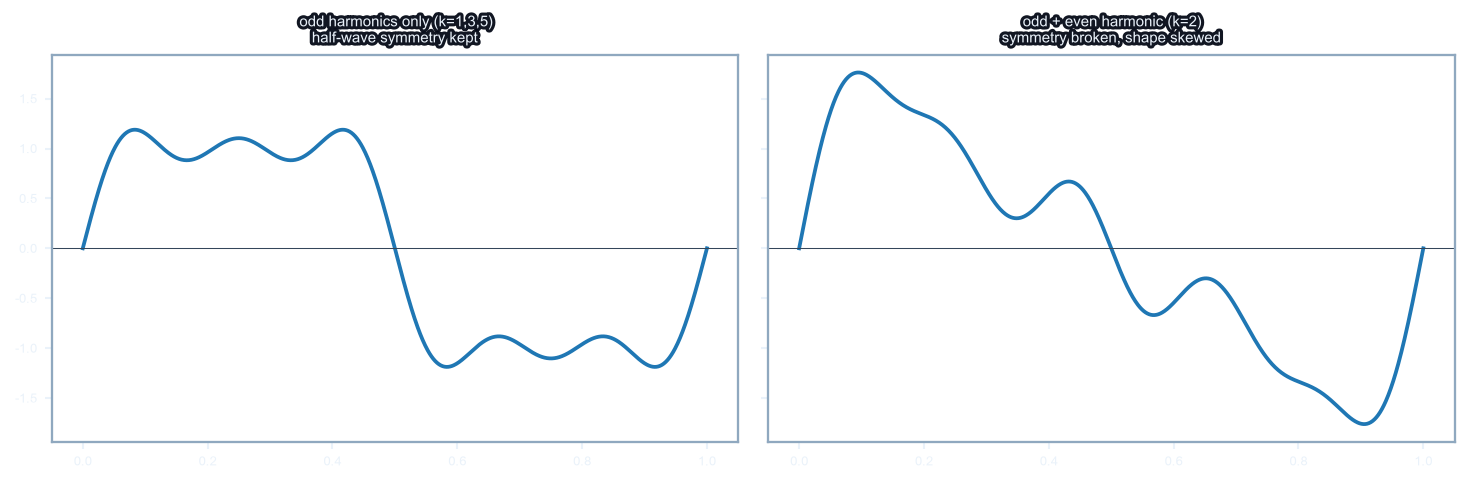

In [2]:
import numpy as np, matplotlib.pyplot as plt

t = np.linspace(0, 1, 1000)

# 只用奇次谐波 k=1,3,5
odd_only = sum((4/(np.pi*k)) * np.sin(2*np.pi*k*t) for k in [1, 3, 5])

# 奇次谐波 + 混入一个偶次谐波 k=2（振幅随便取一个不为零的值，比如 4/(π*2)）
odd_plus_even = odd_only + (4/(np.pi*2)) * np.sin(2*np.pi*2*t)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].plot(t, odd_only); axes[0].set_title('odd harmonics only (k=1,3,5)\nhalf-wave symmetry kept')
axes[1].plot(t, odd_plus_even); axes[1].set_title('odd + even harmonic (k=2)\nsymmetry broken, shape skewed')
for ax in axes:
    ax.axhline(0, color=plt.rcParams["grid.color"], linewidth=0.5)
plt.tight_layout(); plt.show()

print('对比左右两张图：混入偶次谐波后，波形前半段和"平移半周期+翻转"后不再重合——')
print('这就是为什么方波的傅里叶级数里，偶次谐波的系数必须精确为 0。')

## 实验入口：观察谐波叠加

每增加一个奇次谐波，合成波形的边缘就更陡一点，顶部就更平一点。这一格先画基础的 2 Hz + 5 Hz 叠加，后续格把它推广到任意项数。

> 📌 **小提醒**：下面这格的 2 Hz 和 0.5·(5 Hz) 只是随手挑的两个频率，用来演示"随便两个正弦波加在一起，会长成什么样子"——它们之间**不是**谐波关系（5 不是 2 的整数倍），这里还没有"基频"的概念。真正跟"谐波"挂钩的例子在下一节（"动手观察"开始），那里所有频率都是同一个基频的整数倍。先别把这两件事搞混了。

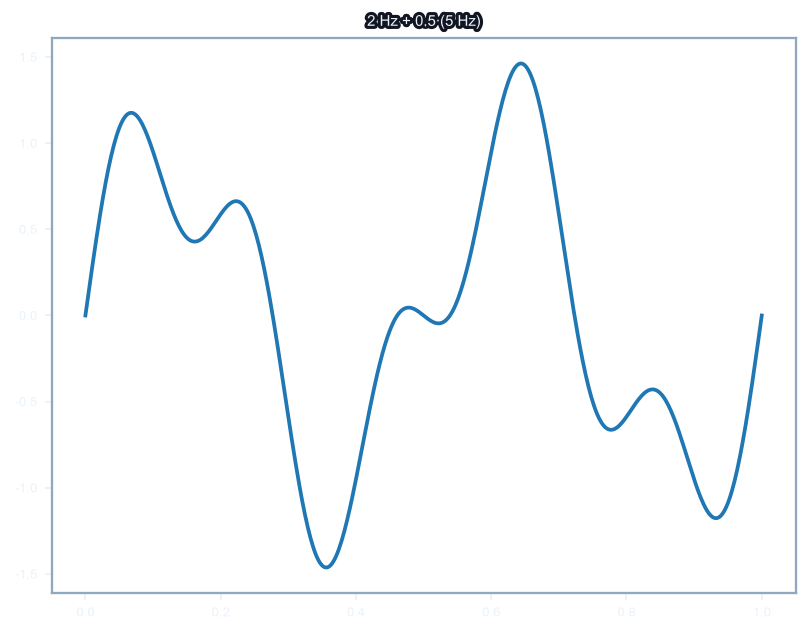

In [3]:
import numpy as np, matplotlib.pyplot as plt
t = np.linspace(0, 1, 500)
y = np.sin(2*np.pi*2*t) + 0.5*np.sin(2*np.pi*5*t)
plt.plot(t, y); plt.title('2 Hz + 0.5·(5 Hz)'); plt.show()

## 动手观察：每个分量长什么样

下面先把前几个奇次谐波单独打印出来。注意第 k 个分量的频率是基频的 k 倍，权重是 1/k——频率越高，贡献越小。

### 先搞懂"谐波"是什么——吉他弦的比喻

拨一根吉他弦，你听到的不是一个单一频率的"纯音"，而是一整个"频率家族"叠在一起：

- 整根弦一起振动，发出最低、最响的那个音，叫**基频**（fundamental frequency，记作 f0）——这就是你说"弹的是哪个音"时说的那个音高。
- 但弦同时也会以"一半长度""三分之一长度"……的方式振动，各自发出 2f0、3f0、4f0……这些更高的频率，只是声音比基频弱很多。这些附加的频率叠加在基频上面，让吉他声音听起来"厚"、"有质感"，而不是像音叉那样单薄。

数学上把这些频率统一编号：

| 编号 k | 频率 | 叫法 |
|---|---|---|
| k=1 | 1×f0 | 基频（1 次谐波） |
| k=2 | 2×f0 | 2 次谐波 |
| k=3 | 3×f0 | 3 次谐波 |
| k=4 | 4×f0 | 4 次谐波 |

**"k 次谐波"就是频率恰好是基频 k 倍的那个正弦分量**——不多不少，必须是整数倍，这是"谐波"这个词的硬性要求（如果频率不是整数倍，就不叫谐波，而是另一个独立的音，就像本课"实验入口"那格里随手挑的 2 Hz + 5 Hz）。

> ⚠️ **一个容易搞混的地方**：音乐里说的"泛音"（overtone）习惯上从基频**之上**数起，所以"第 1 泛音" = 2 次谐波，"第 2 泛音" = 3 次谐波……泛音编号比谐波编号少 1。本课统一使用"k 次谐波"这一套编号（k=1 就是基频本身），避免来回换算搞混。

举个具体例子：钢琴/吉他调音常用的 A4 音高，基频 f0 = 440 Hz。那么：
- 1 次谐波（基频）：440 Hz
- 3 次谐波：3 × 440 = 1320 Hz
- 5 次谐波：5 × 440 = 2200 Hz

下面这段代码打印基频 f0 = 1 Hz 时，前几个**奇次**谐波（1、3、5、7、9 次）分别在 t=0.25 秒时的瞬时值——这正是方波用到的那些频率成分。

In [4]:
import numpy as np

# 前 5 个奇次谐波在 t=0.25 秒处的瞬时值（基频 1 Hz；本表暂不乘统一系数 4/π）
t = 0.25  # 方波首个正半周期的 1/4 位置
print(f"{'阶次':>4}  {'sin(2π×k×t)':>14}  {'权重 1/k':>10}  {'贡献':>10}")
print('-' * 48)
for k in range(1, 10, 2):  # 奇次：1,3,5,7,9
    raw = np.sin(2 * np.pi * k * t)
    weighted = raw / k
    print(f'{k:>4}次  {raw:>+14.4f}  {1/k:>10.4f}  {weighted:>+10.4f}')


  阶次     sin(2π×k×t)      权重 1/k          贡献
------------------------------------------------
   1次         +1.0000      1.0000     +1.0000
   3次         -1.0000      0.3333     -0.3333
   5次         +1.0000      0.2000     +0.2000
   7次         -1.0000      0.1429     -0.1429
   9次         +1.0000      0.1111     +0.1111


### 上面这张表里，符号为什么在 +1、-1 之间跳？——回到单位圆看一眼

观察上面打印的表：k=1 时是 +1.0000，k=3 时是 -1.0000，k=5 时又是 +1.0000……符号规律地正负交替。这不是巧合，而是几何上的必然结果，我们回到 L06 学过的单位圆上看看。

回忆一下：`sin(θ)` 就是单位圆上，从 (1, 0) 出发、逆时针转过 θ 角之后那个点的**纵坐标**。t=0.25 秒时，第 k 次谐波转过的角度是：

```
θ_k = 2π × k × 0.25 = kπ/2
```

- k=1 → θ=π/2=90°，转到圆的正上方 (0, 1)，纵坐标 = **+1**
- k=3 → θ=3π/2=270°，转到圆的正下方 (0, -1)，纵坐标 = **-1**
- k=5 → θ=5π/2=90°+一整圈，转回正上方 (0, 1)，纵坐标 = **+1**
- k=7 → θ=7π/2=270°+一整圈，转到正下方 (0, -1)，纵坐标 = **-1**

因为每次多转半圈（k 每增加 2，多转 π 弧度=180°），落点就在"正上方"和"正下方"之间来回切换——这就是符号交替的几何原因。下面画一个单位圆，把这几个角度对应的点标出来，眼见为实。

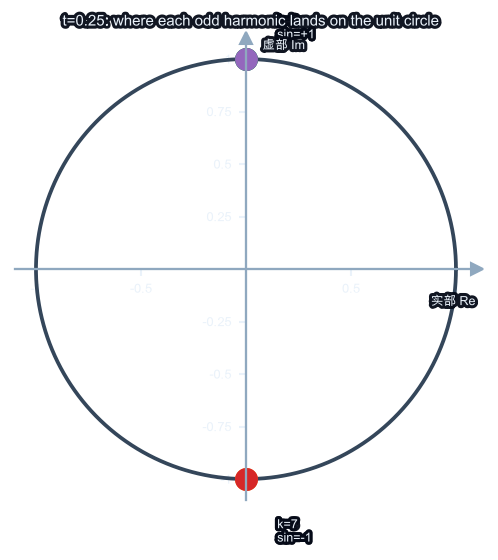

In [5]:
import numpy as np, matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
theta_circle = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta_circle), np.sin(theta_circle), plt.rcParams["grid.color"])

t = 0.25
for k in range(1, 10, 2):
    theta = 2*np.pi*k*t  # = kπ/2
    x, y = np.cos(theta), np.sin(theta)
    ax.plot(x, y, 'o', markersize=10)
    ax.annotate(f'k={k}\nsin={y:+.0f}', (x, y),
                textcoords="offset points", xytext=(15, 10 if y > 0 else -30))

ax.axhline(0, color=plt.rcParams["text.color"], linewidth=0.5)
ax.axvline(0, color=plt.rcParams["text.color"], linewidth=0.5)
ax.set_aspect('equal')
ax.set_title('t=0.25: where each odd harmonic lands on the unit circle')
plt.show()

## 代码实验：叠加项数从 1 到 9

下面从 n=1 到 n=9 逐步增加谐波，观察合成波形的方波近似程度如何随项数提升。

In [6]:
import numpy as np

# 逐步叠加奇次谐波，观察合成值向 π/4 收敛（t=0.25）
t = 0.25
theory = np.pi / 4  # 方波在 t=0.25 的理论值
acc = 0.0
print(f"{'项数':>4}  {'新加谐波':>6}  {'新增贡献':>12}  {'合成值':>12}  {'误差':>10}")
print('-' * 55)
for i, k in enumerate([1, 3, 5, 7, 9]):
    term = np.sin(2 * np.pi * k * t) / k
    acc += term
    print(f'{i+1:>4}  k={k:1d}次  {term:>+12.4f}  {acc:>+12.4f}  {abs(acc-theory):>10.4f}')
print(f'\nπ/4 ≈ {theory:.4f} （越来越近！乘上统一系数 4/π 后正好是方波值 1）')


  项数    新加谐波          新增贡献           合成值          误差
-------------------------------------------------------
   1  k=1次       +1.0000       +1.0000      0.2146
   2  k=3次       -0.3333       +0.6667      0.1187
   3  k=5次       +0.2000       +0.8667      0.0813
   4  k=7次       -0.1429       +0.7238      0.0616
   5  k=9次       +0.1111       +0.8349      0.0495

π/4 ≈ 0.7854 （越来越近！乘上统一系数 4/π 后正好是方波值 1）


### 这个 π/4 到底是什么来头？——一个 350 年前的巧合

上面代码里 `theory = np.pi/4`，你会看到部分和一步步逼近 0.7854……这个数字看起来像凭空冒出来的，但其实我们已经在手里推出来了，只是还没意识到。

回忆上一格单位圆的结论：t=0.25 时，`sin(kπ/2)` 对奇数 k 依次是 +1, -1, +1, -1, ...（k=1,3,5,7,...）。把这个代入部分和：

```
Σ sin(kπ/2)/k  =  1/1 − 1/3 + 1/5 − 1/7 + 1/9 − ...
```

这一串"符号交替、分母是连续奇数"的级数，历史上有个专门的名字——**莱布尼茨级数（Leibniz series）**，17 世纪就被证明恰好收敛到：

```
1 − 1/3 + 1/5 − 1/7 + 1/9 − ... = π/4
```

也就是说，不是我们规定它等于 π/4，而是"单位圆上正负交替的正弦值，按 1/k 权重相加"这件事，数学上被证明必然收敛到 π/4——这是三角函数和圆周率之间一个很深、也很美的联系，完整证明超出了这门课的范围，但知道它是"有名有姓"的经典结果，而不是巧合，应该能让你安心不少。

正因为方波真正的高度是 ±1，而这套级数天生收敛到 π/4，所以才需要接下来那个 4/π 系数，把 π/4"拉伸"回 1——下一节我们就来看这个系数到底怎么来的。

## 2. ✏️ 用奇次谐波叠加逼近方波 `square_approx(t, n)`

方波 ≈ `(4/π) · Σ_{k=1,3,5,...} sin(2π·k·t) / k`（取前 n 个奇次谐波，即每项权重 `4/(πk)`）。

**推理路线**：
1. 输出需与 `t` 等长，先用 `np.zeros_like(t)` 初始化累加器 `result`，确保 dtype 和 shape 自动对齐。
2. 奇次谐波下标是 `1, 3, 5, ..., 2n-1`，用 `range(1, 2*n, 2)` 生成，共 `n` 项。
3. 循环内每次把 `(4/(np.pi*k)) * np.sin(2*np.pi*k*t)` 加到 `result`——分母 `k` 让高频分量权重递减，统一系数 `4/π` 把收敛值从 π/4 拉到方波的 ±1。

**参考输入输出**：`n=1` 时只有基频，输出是标准正弦（峰值 4/π ≈ 1.27）；`n=5` 时波形顶部已出现明显的"肩膀"；`n=50` 时方波的上下平台清晰可见，只在跳变处有吉布斯振铃。

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### 选学 · 想知道「通用求系数法」再看：4/π 到底怎么算出来的？

> 主路径已经够用：半波对称解释「为什么只有奇次」+ 后面数值积分表。  
> 本节是给「想知道换个波形怎么求系数」的人准备的通用方法，**跳过不影响实现 `square_approx`**。

前面我们是"倒推"出系数的：先发现不加系数时极限是 π/4，再"用 4/π 把它拉回 1"。这在数学上说得通，但如果换一个函数——比如三角波、锯齿波——你不可能每次都指望"凑巧收敛到 π/4"。真正通用的做法是什么？

**类比**：想象你面前有一杯"混合果汁"（也就是方波这个信号），你想知道"这杯果汁里，苹果味占多少、橙子味占多少"。如果你有一种神奇的试纸，滴一滴混合果汁上去，试纸只对"苹果味"起反应、对其他味道完全没反应，那你就能精确量出苹果的比例——这就是**正交性（orthogonality）**的意思：不同频率的正弦波，就像互不干扰的"味道试纸"。

数学上这根"试纸"就是**积分**。对周期为 T 的信号 f(t)，如果你想知道"k 次谐波占多少"，就计算：

```
b_k = (2/T) ∫₀ᵀ f(t) · sin(2π·k·t/T) dt
```

背后的原理是：`sin(2π·m·t/T)` 和 `sin(2π·k·t/T)` 这两个不同频率（m≠k）的正弦波，在一个周期内相乘再积分，结果**必然是 0**——就像试纸对其他味道零反应一样。只有当 m=k（自己乘自己）时，积分才不为零，正好"筛"出这个频率自己的系数。这个"筛选"操作就叫傅里叶系数公式，`4/π` 正是把这个积分套在方波上算出来的结果（k=1 时）。

下面这格代码不做符号推导，而是**直接用数值积分**验证这件事：对 k=1 到 6，数值计算 `b_k = (2/T)∫f(t)sin(2πkt/T)dt`，你会看到奇数 k 精确对应 `4/(πk)`，偶数 k 则约等于 0——这就是"为什么只有奇次谐波"最直接的数值证据，不需要死记对称性，让积分自己告诉你答案。

In [7]:
import numpy as np

def square_wave(t, T=1.0):
    # 一个周期 T 的方波：前半周期 +1，后半周期 -1
    return np.where((t % T) < T / 2, 1.0, -1.0)

T = 1.0
t_fine = np.linspace(0, T, 200000, endpoint=False)  # 数值积分用的细网格
dt = t_fine[1] - t_fine[0]
f_vals = square_wave(t_fine, T)

print(f"{'k':>3}  {'数值积分 b_k':>14}  {'理论 4/(πk)（奇）或 0（偶）':>28}")
print('-' * 55)
for k in range(1, 7):
    integrand = f_vals * np.sin(2 * np.pi * k * t_fine / T)
    b_k = (2 / T) * np.sum(integrand) * dt  # 矩形法数值积分
    theory = 4 / (np.pi * k) if k % 2 == 1 else 0.0
    print(f'{k:>3}  {b_k:>14.4f}  {theory:>28.4f}')

  k        数值积分 b_k            理论 4/(πk)（奇）或 0（偶）
-------------------------------------------------------
  1          1.2732                        1.2732
  2         -0.0000                        0.0000
  3          0.4244                        0.4244
  4          0.0000                        0.0000
  5          0.2546                        0.2546
  6          0.0000                        0.0000


### 写代码前，先明确三件事

写 `square_approx` 前明确三件事：
- 输入：`t`（时间数组）、`n`（叠加的谐波个数）
- 关键步骤：对 `k in [1, 3, 5, ..., 2n-1]` 累加 `sin(2π·k·t) / k`
- 返回：与 `t` 等长的一维数组，平台约为 `±1`，跳变处峰值约 `±1.18`（Gibbs 过冲 ≈ 跳变幅度的 9%）

In [8]:
import numpy as np
def square_approx(t, n):
    # 傅里叶级数：(4/πk)·sin(kx)；奇次谐波 k=1,3,5...；截断后平台 ≈ ±1，跳变处峰值 ≈ ±1.18（Gibbs 过冲）
    # ✏️ TODO: 累加前 n 个奇次谐波 (4/πk)·sin(2πkt)，k=1,3,5,...,2n-1
    raise NotImplementedError("TODO: 累加奇次谐波")


In [ ]:
import numpy as np, matplotlib.pyplot as plt
t = np.linspace(0, 1, 1000)
for n in [1, 3, 10]:
    plt.plot(t, square_approx(t, n), label=f'{n} harmonics')
plt.legend(); plt.title('harmonics build a square wave'); plt.show()
# 自检: 谐波越多, 平台越接近 ±1；跳变处 Gibbs 过冲峰值 ≈ 1.18
approx = square_approx(t, 50)
# 峰值应在 [1.05, 1.25]；若 ≈ 0.93 说明漏了系数 4/π，若 > 1.3 可能系数用错
assert 1.05 < approx.max() < 1.25, f'峰值应 ≈ 1.18（Gibbs 过冲），实际 {approx.max():.3f}——若 ≈0.93 请检查是否漏了 4/π'
print('✅ 通过：你亲手用正弦拼出了方波 = 傅里叶级数。')

**🔗 Aurora 连接**：傅里叶变换（Fourier Transform）把信号拆回这些正弦成分（频谱）；L37-L39 的 FFT、L43-L45 的频谱图做的就是这件事。

**🎉 复数与三角地基齐了**：L04–L07 立住了正弦、复数、欧拉、傅里叶级数四块砖，FFT 所需数学已就位。接下来会按路线图进入线代 → 微积分 → 概率，再进音频 DSP。

In [10]:
# 小检查：打印方波前 5 个奇次谐波的频率和幅度
# （这就是 L37-L39 FFT 会「看见」的频谱峰）
import numpy as np
f0 = 440  # 基频 A4
print(f"{'阶次':>4}  {'频率':>9}  {'幅度':>8}  {'说明'}")
print("-" * 42)
for k in range(1, 10, 2):  # 奇次：1,3,5,7,9
    freq = k * f0
    amp  = 4 / (np.pi * k)
    print(f"{k:>4}次  {freq:>8.0f} Hz  {amp:>8.4f}  = 4/(π×{k})")
print()
print("规律：只有奇次谐波；幅度按 1/k 递减。")
print("→ 在 L37 FFT 谱里，这些频率位置会出现对应高度的峰值。")


  阶次         频率        幅度  说明
------------------------------------------
   1次       440 Hz    1.2732  = 4/(π×1)
   3次      1320 Hz    0.4244  = 4/(π×3)
   5次      2200 Hz    0.2546  = 4/(π×5)
   7次      3080 Hz    0.1819  = 4/(π×7)
   9次      3960 Hz    0.1415  = 4/(π×9)

规律：只有奇次谐波；幅度按 1/k 递减。
→ 在 L37 FFT 谱里，这些频率位置会出现对应高度的峰值。


## 参数实验：只改一个旋钮

把 `n` 从 1 增加到 20，观察方波顶部的平坦度如何提高。注意 `t=0.5` 附近的跳变处：即使 `n` 很大，该处的超调量始终接近 9%吉布斯现象（Gibbs phenomenon），增加 `n` 无法消除这个振铃，只能使其向跳变点收缩。

In [11]:
import numpy as np

# 参数实验：谐波项数 n 越大，t=0.25 处近似越精确
t = 0.25
theory = np.pi / 4
print(f"{'n':>5}  {'近似值':>12}  {'误差':>10}")
for n in [1, 3, 5, 10, 20, 50]:
    val = sum(np.sin(2*np.pi*k*t)/k for k in range(1, 2*n, 2))
    print(f'{n:>5}  {val:>+12.6f}  {abs(val-theory):>10.6f}')
print(f'\nπ/4 ≈ {theory:.6f}（乘 4/π 归一化后即方波值 1）')
print('吉布斯现象：即使 n 很大，跳变点附近误差不会完全消失（约 9%）。')


    n           近似值          误差
    1     +1.000000    0.214602
    3     +0.866667    0.081269
    5     +0.834921    0.049522
   10     +0.760460    0.024938
   20     +0.772906    0.012492
   50     +0.780399    0.005000

π/4 ≈ 0.785398（乘 4/π 归一化后即方波值 1）
吉布斯现象：即使 n 很大，跳变点附近误差不会完全消失（约 9%）。


### 那 9% 这个数字到底哪来的？——"用几笔画出一个直角"

想象让你只用几笔又直又软的曲线，去画一个"直角急转弯"（比如方波的跳变）。你会发现：不管加多少笔，笔触在拐角附近总会"冲过头"一点点，因为曲线天生是圆滑的，而拐角是瞬间的、不圆滑的——这正是这里发生的事情：正弦波都是光滑、连续的，而方波的跳变是瞬间发生的，有限项的正弦叠加永远没法在跳变的瞬间"急刹车"，于是在跳变前后会有一点"冲过头"再弹回来的振铃，这就是**吉布斯现象（Gibbs phenomenon）**。

至于精确的"9%"这个数字，它来自一个固定的积分常数（叫作正弦积分 Si(π) ≈ 1.8519），算出来大约是 `(Si(π)/π − 0.5) × 2 ≈ 0.0895`，也就是约 8.95%、四舍五入成"9%"。这个具体推导需要微积分工具，超出本课范围——记住结论就好：**这个 9% 是一个通用常数，只要信号里有"瞬间跳变"，不管是方波还是别的波形，过冲比例都逼近这同一个数字**，感兴趣的话可以搜"Gibbs phenomenon overshoot"看完整推导。

更关键的是下面这句话：**增加项数 n，不会让这 9% 变小，只会让"冲过头"的那一小段区域越变越窄、越贴近跳变点**——过冲的"高度"不变，"宽度"在缩小。下面用代码验证这一点：方波在 t=0（这是从 -1 跳到 +1 的上升沿）右侧一小段，比较 n=10、50、200 时的最大值和它出现的位置。

In [12]:
import numpy as np

def square_approx_local(t, n):
    result = np.zeros_like(t)
    for k in range(1, 2*n, 2):
        result += (4 / (np.pi * k)) * np.sin(2 * np.pi * k * t)
    return result

# t=0 是方波从 -1 跳到 +1 的上升沿；只看它右侧一小段，看"冲过头"的峰值
t_fine = np.linspace(0.001, 0.1, 5000)
print(f"{'n':>5}  {'峰值':>10}  {'超出目标值1':>12}  {'占跳变幅度2的比例':>16}  {'峰值位置 t':>12}")
for n in [10, 50, 200]:
    y = square_approx_local(t_fine, n)
    peak = y.max()
    peak_t = t_fine[np.argmax(y)]
    overshoot = peak - 1
    print(f'{n:>5}  {peak:>10.4f}  {overshoot:>+12.4f}  {overshoot/2:>15.2%}  {peak_t:>12.5f}')
print('\n结论：峰值稳定在约 1.18（超出目标值 1 大约 0.18，占"跳变总幅度"2 的约 9%），')
print('这个比例不随 n 增大而消失；但峰值出现的位置越来越靠近跳变点 t=0，"冲过头"的区域在收缩。')

    n          峰值        超出目标值1         占跳变幅度2的比例        峰值位置 t


   10      1.1798       +0.1798            8.99%       0.02500
   50      1.1790       +0.1790            8.95%       0.00500


  200      1.1789       +0.1789            8.95%       0.00126

结论：峰值稳定在约 1.18（超出目标值 1 大约 0.18，占"跳变总幅度"2 的约 9%），
这个比例不随 n 增大而消失；但峰值出现的位置越来越靠近跳变点 t=0，"冲过头"的区域在收缩。


## 本课收束

现在能用 `square_approx(t, n)` 生成任意项数的谐波叠加，并观察合成波形随 n 收敛的过程。这直接对应 `aurora.audio.transforms` 的工作原理：FFT 输出的每个频率桶，都在说某个正弦分量有多响、相位如何。STFT 只是在每个时间帧上重复这件事，于是得到频谱图的一列。L37-L39 实现离散 FFT 时，会用方波信号验证频谱中只有奇次谐波出现。

下一课（L08）将通过 matplotlib 动画演示复数平面上的单位圆旋转、共轭对称与相位概念，把傅里叶直觉映射到可视化图像。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


### 白板挑战前先备好："几个常用角"速查表

下面这些角度会在推导里反复出现（尤其是 π/2、3π/2 这种）。与其每次现算，不如先把这张表印在脑子里——或者干脆抄在草稿纸最上面，推导时随时看。

In [13]:
import numpy as np

angles = [
    ('0', 0),
    ('π/6', np.pi/6),
    ('π/4', np.pi/4),
    ('π/3', np.pi/3),
    ('π/2', np.pi/2),
    ('2π/3', 2*np.pi/3),
    ('3π/4', 3*np.pi/4),
    ('5π/6', 5*np.pi/6),
    ('π', np.pi),
    ('3π/2', 3*np.pi/2),
    ('2π', 2*np.pi),
]
print(f"{'角度':>6}  {'弧度值':>8}  {'sin':>8}  {'cos':>8}")
print('-' * 36)
for name, theta in angles:
    print(f'{name:>6}  {theta:>8.4f}  {np.sin(theta):>+8.4f}  {np.cos(theta):>+8.4f}')

    角度       弧度值       sin       cos
------------------------------------
     0    0.0000   +0.0000   +1.0000
   π/6    0.5236   +0.5000   +0.8660
   π/4    0.7854   +0.7071   +0.7071
   π/3    1.0472   +0.8660   +0.5000
   π/2    1.5708   +1.0000   +0.0000
  2π/3    2.0944   +0.8660   -0.5000
  3π/4    2.3562   +0.7071   -0.7071
  5π/6    2.6180   +0.5000   -0.8660
     π    3.1416   +0.0000   -1.0000
  3π/2    4.7124   -1.0000   -0.0000
    2π    6.2832   -0.0000   +1.0000


## ✏️ 白板挑战：傅里叶级数手算（目标 10 分钟）

盖上屏幕，纸上作答。公式：`square_approx(t, n) = (4/π) · Σ_{k=1,3,5,...,2n-1} sin(2π·k·t) / k`

**问 1**：n=1 时（只有 k=1 项），`square_approx(0.25, 1)` 等于多少？
提示：`(4/π) · sin(2π·1·0.25) = (4/π) · sin(π/2) = ?`

**问 2**：理论上，当 n→∞ 时，`square_approx(0.25, n)` 收敛到多少？
（方波在 t=0.25 处的真实值是 +1）

**问 3**：n=2 时（k=1 和 k=3），`square_approx(0.25, 2)` 等于多少？
提示：加上 k=3 的贡献：`(4/π) · sin(2π·3·0.25) / 3 = (4/3π) · sin(3π/2) = ?`（注意方向！）

**问 4**：在 t=0.5（方波的跳变点），任意有限项 n 的叠加结果是多少？为什么？
提示：所有正弦 `sin(2π·k·0.5) = sin(kπ) = 0`（k 为整数）。

> 💡 **问 4 的延伸思考**：你算出来级数在 t=0.5 处收敛到 0，但方波在跳变点到底该取 +1 还是 -1？两个都不对，也两个都对——数学上有个专门的约定（**狄利克雷定理**，Dirichlet's theorem）：在跳变点，傅里叶级数收敛到**左极限和右极限的平均值**，也就是 `(+1 + (-1)) / 2 = 0`。所以级数给出的 0 不是"算错了"或"没定义"，而是这一点上唯一自洽、大家都认可的取值——跳变点本身更像是"两个平台之间的中线"，而不属于任何一边。

推导完成后运行下面格对答案。

In [14]:
# ✏️ 对答案格
import numpy as np

# 问1：n=1 时 t=0.25
n1 = (4/np.pi) * np.sin(2*np.pi * 1 * 0.25) / 1
assert np.isclose(n1, 4/np.pi, atol=1e-10)
print(f"Q1 ✅  n=1, t=0.25: (4/π)·sin(π/2) = 4/π ≈ {n1:.4f}")

# 验证用 square_approx
try:
    t_arr = np.array([0.25])
    q1_code = square_approx(t_arr, 1)[0]
    assert np.isclose(q1_code, n1, atol=1e-10), f"square_approx 值 {q1_code:.4f} 与手算 {n1:.4f} 不符"
    print(f"       square_approx(0.25, 1) = {q1_code:.4f}  ✅ 与手算一致")
except (NotImplementedError, TypeError):
    print("       (square_approx 尚未实现，先手算对答案)")

# 问2：理论极限
print(f"\nQ2 ✅  n→∞ 时收敛到 1.0（方波真实值）；跳变处 Gibbs 过冲到约 ±1.18（≈跳变幅度的 9%）")

# 问3：n=2 时 t=0.25
k1_contrib = (4/np.pi) * np.sin(2*np.pi * 1 * 0.25) / 1
k3_contrib = (4/np.pi) * np.sin(2*np.pi * 3 * 0.25) / 3  # = (4/3π)·sin(3π/2) = -4/(3π)
n2 = k1_contrib + k3_contrib
print(f"\nQ3 ✅  n=2, t=0.25: {k1_contrib:.4f} + ({k3_contrib:.4f}) = {n2:.4f}")
print(f"       k=1 贡献正 4/π，k=3 贡献负 4/(3π)，部分相消后更接近 1")

# 问4：t=0.5 跳变点
for n in [1, 3, 5, 10]:
    try:
        val_at_half = square_approx(np.array([0.5]), n)[0]
        assert np.isclose(val_at_half, 0.0, atol=1e-10), f"n={n}: 期望0，得到{val_at_half}"
    except (NotImplementedError, TypeError):
        # 手算验证
        val_at_half = sum((4/(np.pi*k)) * np.sin(2*np.pi*k*0.5) for k in range(1, 2*n, 2))
        assert abs(val_at_half) < 1e-10
print(f"\nQ4 ✅  任意 n，t=0.5 处叠加结果 = 0（sin(kπ)=0 对所有整数k成立）")
print("       这个 0 就是狄利克雷定理说的'左极限(+1)与右极限(-1)的平均值'，不是未定义。")
print("\n🎉 傅里叶直觉白板挑战通过！正弦叠加=方波的手算已内化。")

Q1 ✅  n=1, t=0.25: (4/π)·sin(π/2) = 4/π ≈ 1.2732
       (square_approx 尚未实现，先手算对答案)

Q2 ✅  n→∞ 时收敛到 1.0（方波真实值）；跳变处 Gibbs 过冲到约 ±1.18（≈跳变幅度的 9%）

Q3 ✅  n=2, t=0.25: 1.2732 + (-0.4244) = 0.8488
       k=1 贡献正 4/π，k=3 贡献负 4/(3π)，部分相消后更接近 1

Q4 ✅  任意 n，t=0.5 处叠加结果 = 0（sin(kπ)=0 对所有整数k成立）
       这个 0 就是狄利克雷定理说的'左极限(+1)与右极限(-1)的平均值'，不是未定义。

🎉 傅里叶直觉白板挑战通过！正弦叠加=方波的手算已内化。


### 自评前先想清楚："理解"到底要求到什么程度？

下面每一项自评不是"回忆起这个词"就算过关，而是要能对着别人（或自己）说出**为什么**。作为参考标准：

- **`square_approx_implemented`**：函数写出来，`assert` 断言真的跑通了（不是"应该没问题"）。
- **`harmonic_series_understood`**：你能不看 notebook，口头说出——为什么只有奇次谐波（半波对称、或积分为零）、系数 4/π 是怎么来的（正交积分，至少知道"不是拍脑袋定的"）、权重为什么按 1/k 衰减。三点里能说清楚两点，就算理解。
- **`gibbs_phenomenon_intuition`**：你能说出 Gibbs 现象的两个关键点——① 跳变处必然过冲，约 9%；② 增加项数**不会消除**过冲，只会让过冲区域变窄。只答出"跳变处有振铃"不算完整。
- **`whiteboard_passed`**：4 道题都是自己纸上推出来的，不是看完代码答案才反推的。

如果某一项你现在说不清楚，回去看对应的小节，而不是直接勾 True——这份自评是给自己看的，混过去没有意义。

In [15]:
# ✏️ 本课自评
l07_review = {
    "square_approx_implemented": None,  # square_approx 实现并通过断言？True/False
    "harmonic_series_understood": None, # 理解奇次谐波 + 1/k 权重的傅里叶级数结构？True/False
    "gibbs_phenomenon_intuition": None, # 知道 Gibbs 现象（跳变处超调≈9%）？True/False
    "whiteboard_passed":          None, # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l07_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l07_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L07 全部通关！进入 L08：复数平面可视化')

---

→ **下一课**　[L08 · 复数平面可视化](L08_visual_complex.ipynb)

> 下节课将学习 **复数平面可视化**：单位圆旋转、共轭与相位，matplotlib 动态演示。